 # MKA-MLF, Lab_07 Convolutional Neural Networks

## Exercise - XOR Gate

## Exercise - Hand-written digits recognition

Create CNN which will process and recognize handwritten digits. For this purposes please use the MNIST database (Modified National Institute of Standards and Technology database) which is a large database of handwritten digits that is commonly used for training various image processing systems.

The datasample of the MNIST datasets can be see in the following picture

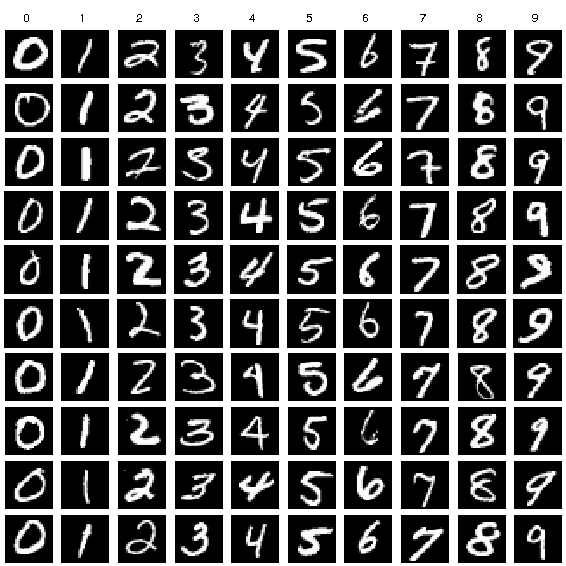

### Task description

In the terms of machine learning, the Hand-written digits recognition can be threated as a multi-class classification problem. This is very important knowledge to structure our model in the correct way (Especially the output-layer, including the number of neurons and activations function and the overall loss function and classification metrics)

### 0. Import libraries

Import the all necessary libraries, you can get inspired by the previous exercises. You can improst the libraries gradually, when do you progressing with the task

In [1]:
# Due to problems with TensorFlow's GPU implementation, I completely rewrote the cells to a single large functions.
# Mainly had to remove all TensorFlow imports and GPU stuff from the global scope because of GPU memory issues (TensorFlow would eventually use up all memory)
# All cells except this one and the last two now contain only function definitions and are used in the last two cells.

import os, glob, ctypes, sysconfig

# 1. Inject the Windows/WSL bridge
ctypes.CDLL("/usr/lib/wsl/lib/libcuda.so.1", mode=ctypes.RTLD_GLOBAL)

# 2. Inject all pip-installed NVIDIA libraries
for lib in glob.glob(os.path.join(sysconfig.get_path('purelib'), 'nvidia', '*', 'lib', '*.so*')):
    try: ctypes.CDLL(lib, mode=ctypes.RTLD_GLOBAL)
    except: pass

import multiprocessing as mp
import pandas as pd
import time
import os
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
###################################
# Write your own code here #


###################################
font = {'weight' : 'bold',
        'size'   : 12}

matplotlib.rc('font', **font)

single_run = False

### 1. Dataset

#### 1.1 Load Dataset

You can load the dataset using the following code

In [2]:
# from keras.datasets import mnist
# (X_train, y_train), (X_test, y_test) = mnist.load_data()

#### 1.2 Dataset examination

Using the following code, display random images,

In [3]:
def display_random_images(x_data: np.array, y_data: np.array, count: int = 10) -> None:
  index = np.array(len(x_data))
  selected_ind = np.random.choice(index, count)

  selected_img = x_data[selected_ind]
  selected_labels = y_data[selected_ind]
  concat_img = np.concatenate(selected_img, axis=1)

  plt.figure(figsize=(20,10))
  plt.imshow(concat_img, cmap="gray")

  for id_label, label in enumerate(selected_labels):
    plt.text(14 + 28*id_label, 28*(5/4), label)
  plt.axis('off')
  plt.show()

In [4]:
# display_random_images(X_train, y_train)

Examine the dataset. Answer for yourself the following questions:

- What kind of data occurs in our dataset?
- How many data samples do we have in train and test datasets?
- How many colour channels does the input variable have?
- What is the size of the input images?
- What is the necessary preprocessing of the input data X?
- How many classes do we have in target varoable?
- What is the necessary preprocessing of target variable y?

In [5]:
def get_hyperparams() -> dict:
  return {
    'Optimizer': 'Adam',
    'hidden_layers': 2,
    'activations': 'relu',
    'hidden_units': [128, 64],
    'Learning Rate': 0.001,
    'Epochs': 100,
    'Batch Size': 128,
    'L2 Penalty': 0.001,
    'Dropout Rate': 0.2,
    'Compression Factor': 0.5
  }

#### 1.3 Dataset preprocessing

Perform the necessary data preprocessing. The best way to preprocess the data would be one hot encoding for the target variable and normalization for the input variable (using min-max or z-score normalization)

In [6]:
###################################
# Write your own code here #
def data_preprocessing() -> tuple:
  from keras.utils import to_categorical
  from keras.datasets import mnist
  (x_train, y_train), (x_test, y_test) = mnist.load_data()
  x_train = x_train.astype('float32') / 255.0
  x_test = x_test.astype('float32') / 255.0
  x_train = np.expand_dims(x_train, axis=-1)
  x_test = np.expand_dims(x_test, axis=-1)
  
  y_train = to_categorical(y_train, num_classes = 10)
  y_test = to_categorical(y_test, num_classes = 10)
  return (x_train, y_train), (x_test, y_test)


###################################

In [7]:
# (x_train, y_train), (x_test, y_test) = data_preprocessing()

### 2. Build the model

In this section, your task will be to define the model architecture. The intial structure can be defined as follows:

Input_layer -> Convolutional_layer(kernel_size=(3,3), no_channels=32) -> Maxpooling_layer(kernel_size=(2, 2)) -> Flatten_layer -> Dense_layer (num_classes)
    
    


#### 2.1 Define the model structure

In [17]:
###################################
# Write your own code here #
def build_model(params: dict):
  from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
  from keras.models import Sequential

  model = Sequential()
  model.add(Conv2D(32, kernel_size=(3, 3), activation='elu', input_shape = (28, 28, 1)))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Conv2D(64, kernel_size=(5, 5), activation='relu'))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dropout(params['Dropout Rate']))
  model.add(Dense(256, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  
  return model


###################################


#### 2.2 Compile the model

Build the model, use the relevant metrics, optimizer and loss function. While choosing the metrics and loss function, consider fact that we are are trying to solve the multiclass classification problem 

In [9]:

###################################
# Write your own code here #
def compile_model(model, params: dict) -> None:
    from keras.optimizers import Adam

    loss = 'categorical_crossentropy'
    learning_rate = params['Learning Rate']
    optimizer = None
    if params['Optimizer'] == 'Adam':
        optimizer = Adam(learning_rate=learning_rate)
    metrics = ['accuracy']
    model.compile(optimizer=optimizer,
                    loss=loss,
                    metrics=metrics)


###################################
    # model.summary()

### 3. Training stage

#### 3.1 Model training

train your model, define the relevant hyperparameters (no. epochs, batch_size), use 20p of the training data for validation

In [10]:
###################################
# Write your own code here #
def train_model(model, x_data: np.array, y_data: np.array, params: dict, verbose: int) -> None:
    batch_size = params['Batch Size']
    epochs = params['Epochs']
    from keras.callbacks import EarlyStopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
    model.fit(x_data, y_data, batch_size=batch_size, epochs=epochs, verbose=verbose, validation_split=0.2, callbacks=[early_stopping])

###################################

#### 3.1 Model Evaluation on validation data

Plot the development of the training and validation loss, and training and validation metrics.

In [11]:
###################################
# Write your own code here #
def plot_eval_history(history) -> None:
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()



###################################

### 4. Model evaluation

Evaluate the model on the testing dataset using the relevant metrics. Use the confusion metrics as the one of the metrics.

In [12]:
###################################
# Write your own code here #
def evaluate_model(model, x_test: np.array, y_test: np.array, verbose: int) -> tuple:
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=verbose)
    print(f'Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}')
    return test_acc, test_loss


###################################

### 5. Hyperparameter tunning and regularization techniques

When your code is ready and fully functional, try several changes in the hyperparameters and see how they influence the testing metrics. Try changes in the network structure. You can also try adding regularization techniques such as L1, L2, and Dropout. Based on the development of training and validation loss, try to identify overfitting and avoid it

Starting Process-Isolated Search: 1 Trials...



/home/mga/school/8_semestr/MLF/Garncarz_MPA_MLF/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 9, 9, 64)       │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,554 (1.21 MB)

 Trainable params: 316,554 (1.21 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9324 - loss: 0.2266 - val_accuracy: 0.9762 - val_loss: 0.0748
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9797 - loss: 0.0648 - val_accuracy: 0.9849 - val_loss: 0.0486
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9864 - loss: 0.0452 - val_accuracy: 0.9862 - val_loss: 0.0441
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9890 - loss: 0.0351 - val_accuracy: 0.9890 - val_loss: 0.0380
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9909 - loss: 0.0275 - val_accuracy: 0.9899 - val_loss: 0.0364
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9922 - loss: 0.0240 - val_accuracy: 0.9912 - val_loss: 0.0353
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9939 - loss: 0.0180 - val_accuracy: 0.9907 - val_loss: 0.0382
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9937 - loss: 0.0179 - val_acc

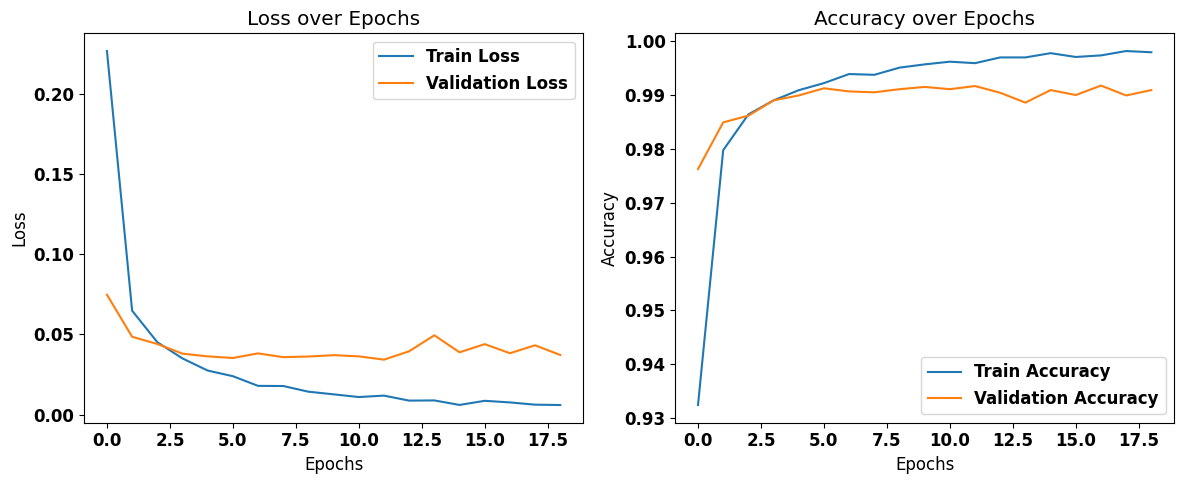

Test accuracy: 0.9917, Test loss: 0.0286
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


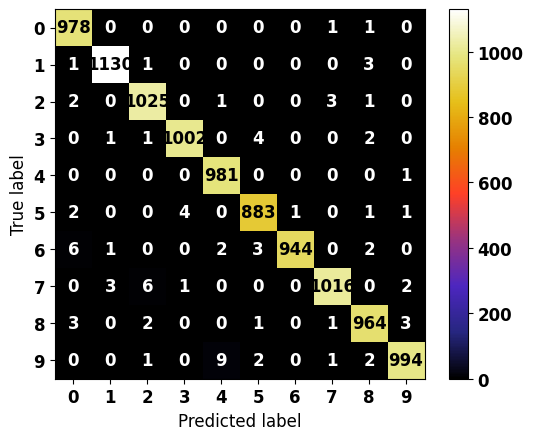

Iteration    1/1 completed in  66.63 s with Val Accuracy: 99.17%

Search Complete! Time since start: 73.75 seconds


In [18]:
csv_filename = 'results.csv'
num_trials = 1


def run_single_trial(trial_num, params) -> tuple:
    os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async" # set GPU allocator
    os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Suppress TensorFlow logging (1 = INFO, 2 = WARNING, 3 = ERROR)
    os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0' # Disable oneDNN optimizations to reduce GPU memory fragmentation

    import warnings
    warnings.filterwarnings('ignore', category=np.exceptions.VisibleDeprecationWarning)
    
    import absl.logging
    absl.logging.set_verbosity(absl.logging.ERROR) # Disable some logging from Tensorflow

    import tensorflow as tf
    
    # Enable Memory Growth
    physical_devices = tf.config.list_physical_devices('GPU')
    if physical_devices:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
        
    # Load data locally for this process and preprocess them

    (x_train, y_train), (x_test, y_test) = data_preprocessing()
    # x_train, x_test = x_train / 255.0, x_test / 255.0
    # y_train, y_test = tf.keras.utils.to_categorical(y_train, num_classes=10), tf.keras.utils.to_categorical(y_test, num_classes=10)
    
    # Model definition and training with random hyperparameters
    # print(f'Iteration {trial_num}/{num_trials} started...')

    start_time = time.time()
    model = build_model(params)
    model.summary()
    compile_model(model, params)
    train_model(model, x_data=x_train, y_data=y_train, params=params, verbose=1)
    plot_eval_history(model.history)
    acc, _ = evaluate_model(model, verbose=0, x_test=x_test, y_test=y_test)
    end_time = time.time()

    # result_df = pd.DataFrame([{
    #     'Trial': trial_num, 'Optimizer': params['Optimizer'],
    #     'Layers': params['hidden_layers'], 'Activation': params['activations'], 'Initial_neurons': params['hidden_units'][0],
    #     'Learning_Rate': params['Learning Rate'], 'Batch_Size': params['Batch Size'],
    #     'L2_Penalty': params['L2 Penalty'], 'Dropout_Rate': params['Dropout Rate'], 'Compression_Factor': params['Compression Factor'], 'Time': round(end_time - start_time, 2), 'Val_Accuracy': round(acc, 4) * 100
    # }])
    # result_df.to_csv(csv_filename, mode='a', header=False, index=False)

    from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
    y_pred = model.predict(x_test)
    y_pred = np.argmax(y_pred, axis=1)
    y_test = np.argmax(y_test, axis=1)

    # res = confusion_matrix(y_pred=y_pred, y_test=y_test)
    # disp = ConfusionMatrixDisplay(confusion_matrix=res, display_labels=np.arange(10))
    # disp.plot(cmap=plt.cm.Dark2)

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap=plt.cm.CMRmap, display_labels=np.arange(10))
    plt.show()


    print("Iteration {trial_num:4.0f}/{num_trials} completed in {time:6.2f} s with Val Accuracy: {acc:4.2f}%".format(trial_num=trial_num, num_trials=num_trials, acc=acc*100, time=end_time - start_time))
    return



if __name__ == '__main__':
    print(f"Starting Process-Isolated Search: {num_trials} Trials...\n")
    start_time = time.time()
    # print("Start time: {time:.2f} s".format(time=start_time))

    # if not os.path.exists(csv_filename):
    #     pd.DataFrame(columns=[
    #         'Trial', 'Optimizer', 'Layers', 'Activation', 'Initial neurons',
    #         'Learning Rate', 'Batch Size', 'L2 Penalty', 'Dropout Rate', 'Compression Factor', 'Time', 'Val Accuracy'
    #     ]).to_csv(csv_filename, index=False)
    
    for trial in range(1, num_trials + 1):
        manager = mp.Manager()
        # Spawn the isolated process
        params = get_hyperparams()  # Initialize with random hyperparameters
        p = mp.Process(target=run_single_trial, args=(trial, params))
        p.start()

        p.join() 
        # print("Time since start: {time:.2f} seconds".format(time=time.time() - start_time))

    print("\nSearch Complete! Time since start: {time:.2f} seconds".format(time=time.time() - start_time))